# 04. Direction-Only Hard Constraint Cumulative Drift

The first hard-constraint attempt fixed one safety axis but left another axis broken. It forced the sequence to move in the correct direction: during discharge, predicted SOC could only decrease. That was enough to drive PVR to zero. It was not enough to make the trajectory physically meaningful.

Direction alone says `delta_SOC <= 0`. Coulomb counting says more: `|delta_SOC| <= |I| * dt / (Q_nom * 3600)`, up to a conservative safety factor. Without this magnitude envelope, a network can output a very large negative delta every second, drive SOC below zero, and hide the damage behind a final `[0, 1]` clip. The result is zero PVR and massive cumulative drift.

This notebook captures that failure: hard monotonicity without Coulomb magnitude is not enough. Safety needs both direction and rate.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'logs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and logs/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})
print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Load Sprint 45 direction-only ledger

Sprint 45 is the failure we want reviewers to see. It got PVR to zero, but Scenario A MaxE exploded to almost 100 percentage points. That is the signature of monotone cumulative drift: the model obeyed direction while losing physical scale.


In [2]:
log_path = ROOT / 'logs' / 'sprint45_results_v4_lstm.json'
if not log_path.exists():
    raise FileNotFoundError(log_path)
data = json.loads(log_path.read_text(encoding='utf-8'))
rows = []
for key, row in data.items():
    rows.append({
        'Scenario': row['scenario'].replace('_', ' ').title(),
        'RMSE full (%)': float(row['rmse_full_pct']),
        'MaxE full (%)': float(row['max_error_full_pct']),
        'PVR (%)': float(row['pvr']),
        'Violations': int(row['pvr_violations']),
        'Discharge steps': int(row['pvr_discharge_steps']),
        'Samples': int(row['n_samples']),
    })
drift_df = pd.DataFrame(rows)
display(drift_df.round({'RMSE full (%)': 3, 'MaxE full (%)': 3, 'PVR (%)': 6}))
scenario_a_maxe = float(drift_df[drift_df['Scenario'] == 'Scenario A']['MaxE full (%)'].iloc[0])
assert scenario_a_maxe > 99.0, 'Scenario A MaxE should expose direction-only drift failure.'
assert (drift_df['PVR (%)'] == 0.0).all(), 'Direction-only hard constraint should show zero PVR in this ledger.'


,Scenario,RMSE full (%),MaxE full (%),PVR (%),Violations,Discharge steps,Samples
0,Scenario A,14.681,99.898,0.0,0,13177375,194302
1,Scenario B,4.355,68.518,0.0,0,5902702,89844


## Runaway drift demonstration

The line plot below is a schematic driven by the Sprint 45 error scale. It shows how a direction-only model can remain monotone while accumulating impossible negative SOC motion. The final clip hides the raw trajectory below zero but cannot repair the lost state estimate.


In [3]:
t = np.arange(0, 220)
true_soc = 98.0 - 0.025 * t
drift_scale = scenario_a_maxe
raw_direction_only = true_soc - drift_scale * (t / t.max()) ** 1.35
clipped_direction_only = np.clip(raw_direction_only, 0.0, 100.0)
coulomb_bounded = true_soc - 1.8 * (t / t.max())

diagnostic = pd.DataFrame({
    'Trajectory': ['True SOC', 'Direction-only raw', 'Direction-only clipped', 'Coulomb-bounded reference'],
    'Final SOC (%)': [true_soc[-1], raw_direction_only[-1], clipped_direction_only[-1], coulomb_bounded[-1]],
    'Minimum SOC (%)': [true_soc.min(), raw_direction_only.min(), clipped_direction_only.min(), coulomb_bounded.min()],
})
display(diagnostic.round(3))


,Trajectory,Final SOC (%),Minimum SOC (%)
0,True SOC,92.525,92.525
1,Direction-only raw,-7.373,-7.373
2,Direction-only clipped,0.000,0.000
3,Coulomb-bounded reference,90.725,90.725


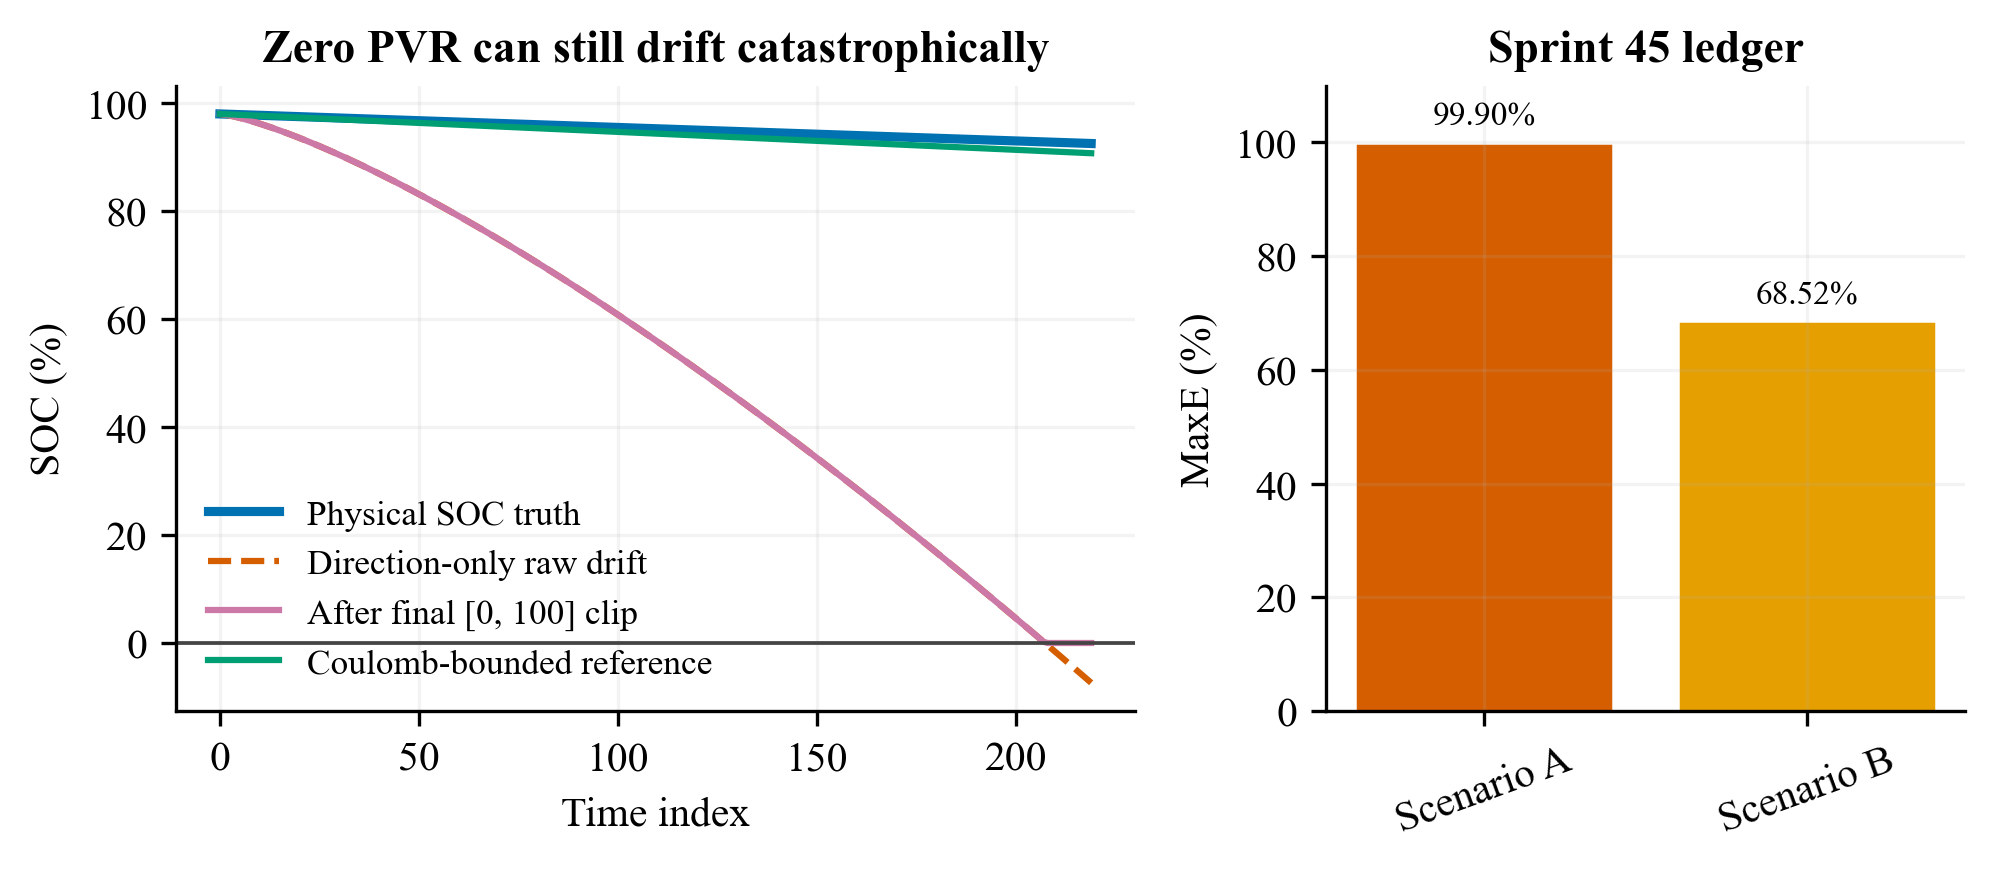

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_04_direction_only_cumulative_drift.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_04_direction_only_cumulative_drift.png


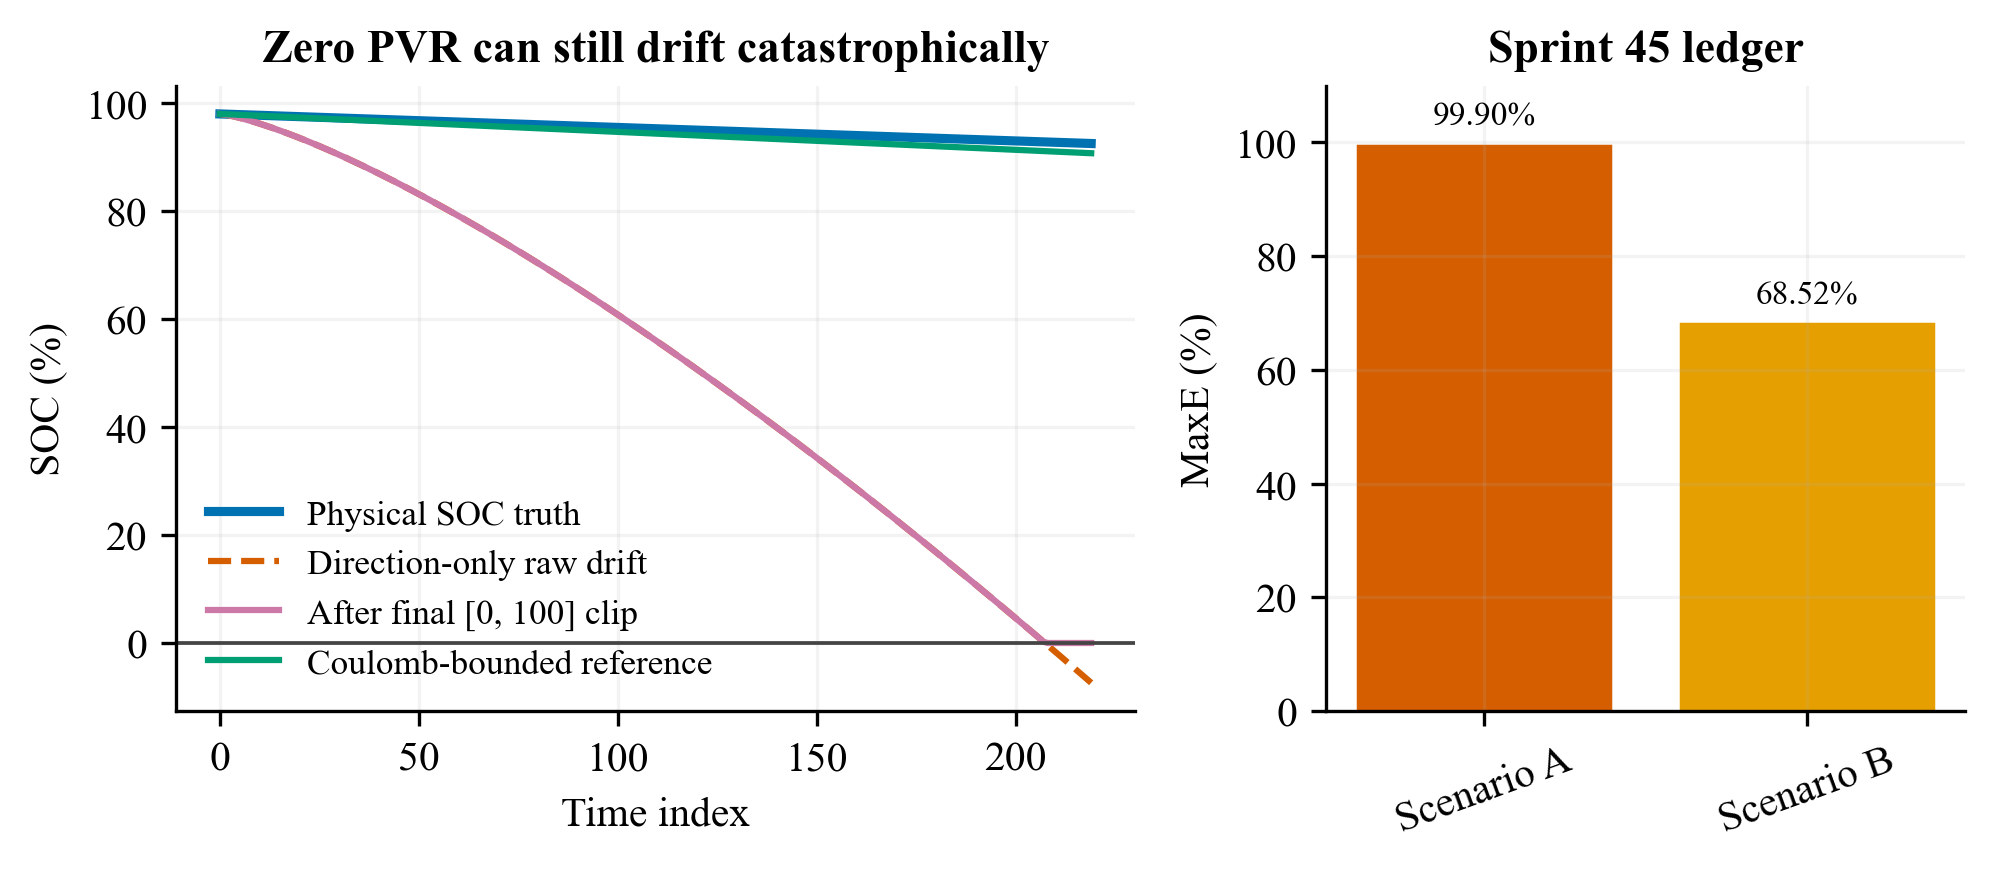

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6.75, 3.0), gridspec_kw={'width_ratios': [1.5, 1.0]})
ax = axes[0]
ax.plot(t, true_soc, color='#0072B2', label='Physical SOC truth', linewidth=2.2)
ax.plot(t, raw_direction_only, color='#D55E00', linestyle='--', label='Direction-only raw drift')
ax.plot(t, clipped_direction_only, color='#CC79A7', label='After final [0, 100] clip')
ax.plot(t, coulomb_bounded, color='#009E73', label='Coulomb-bounded reference')
ax.axhline(0, color='#444444', linewidth=0.9)
ax.set_xlabel('Time index')
ax.set_ylabel('SOC (%)')
ax.set_title('Zero PVR can still drift catastrophically')
ax.legend(loc='lower left')

bar_ax = axes[1]
bar_colors = ['#D55E00' if s == 'Scenario A' else '#E69F00' for s in drift_df['Scenario']]
bars = bar_ax.bar(drift_df['Scenario'], drift_df['MaxE full (%)'], color=bar_colors, edgecolor='white', linewidth=0.6)
for bar, value in zip(bars, drift_df['MaxE full (%)']):
    bar_ax.text(bar.get_x() + bar.get_width() / 2, value + 2.0, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
bar_ax.set_ylabel('MaxE (%)')
bar_ax.set_ylim(0, max(110, drift_df['MaxE full (%)'].max() + 8))
bar_ax.set_title('Sprint 45 ledger')
bar_ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_04_direction_only_cumulative_drift.pdf'
png_path = FIG_DIR / 'fig_04_direction_only_cumulative_drift.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

Direction-only hard constraints solved the sign of SOC motion but ignored the magnitude of motion. The MaxE failure proves that `PVR = 0` alone is not a complete model. The final architecture had to bind each delta to the Coulomb envelope set by current, time step, and nominal capacity.
